# Teams : PowerRangers

*Team members : Nicolas CORNU LAPORTE, Alix GALANT, Athenais MENDY*

**Target** : ...




100%|██████████| 251k/251k [00:00<00:00, 536kB/s]

Extracting files...



 Training model : Random Forest
--- Report Assessment for model Random Forest ---
Global Accuracy : 0.6646
ROC-AUC score : 0.6579

Classification Report :
              precision    recall  f1-score   support

           0       0.67      0.89      0.76       400
           1       0.64      0.32      0.42       256

    accuracy                           0.66       656
   macro avg       0.66      0.60      0.59       656
weighted avg       0.66      0.66      0.63       656



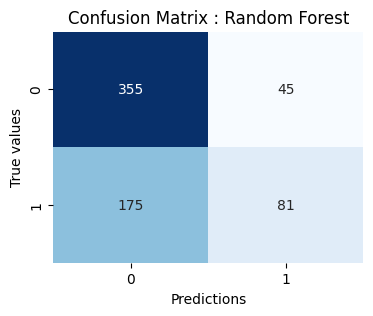


 Training model : Gradient Boosting
--- Report Assessment for model Gradient Boosting ---
Global Accuracy : 0.6601
ROC-AUC score : 0.6551

Classification Report :
              precision    recall  f1-score   support

           0       0.66      0.90      0.76       400
           1       0.65      0.29      0.40       256

    accuracy                           0.66       656
   macro avg       0.65      0.59      0.58       656
weighted avg       0.66      0.66      0.62       656



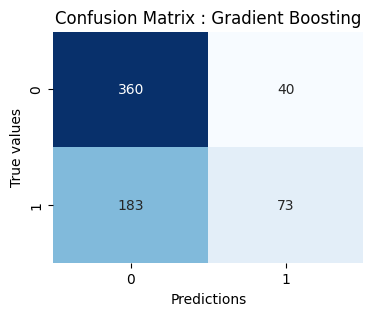


 Training model : XGBoost
--- Report Assessment for model XGBoost ---
Global Accuracy : 0.6799
ROC-AUC score : 0.6602

Classification Report :
              precision    recall  f1-score   support

           0       0.68      0.90      0.77       400
           1       0.68      0.34      0.46       256

    accuracy                           0.68       656
   macro avg       0.68      0.62      0.61       656
weighted avg       0.68      0.68      0.65       656



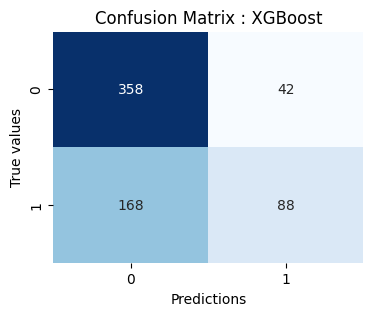


=== FINAL RESULTS COMPARISON ===
                   Accuracy   ROC-AUC
Random Forest      0.664634  0.657930
Gradient Boosting  0.660061  0.655078
XGBoost            0.679878  0.660215


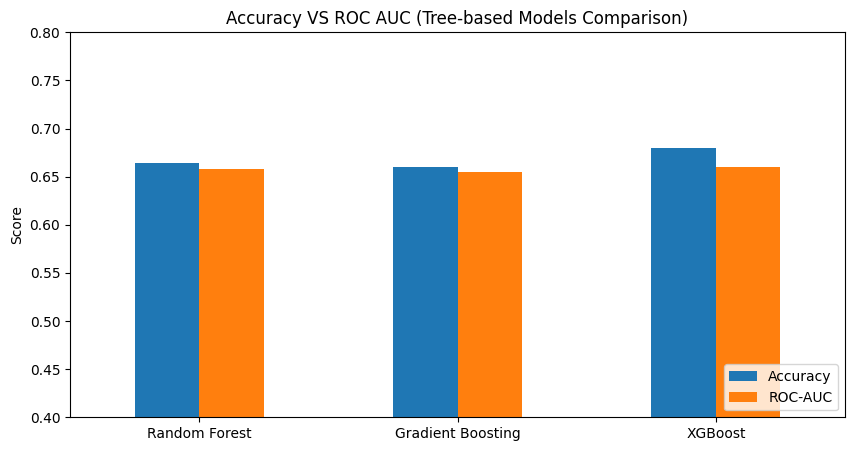

Saving Models : web/model\random_forest.pkl
Saving Models : web/model\gradient_boosting.pkl
Saving Models : web/model\xgboost.pkl


In [ ]:
"""
# Water Potability Prediction

## Problem Definition
Access to safe drinking water is a fundamental human right and a critical factor for public health.
The objective of this project is to build a machine learning model capable of predicting whether a
water sample is safe for human consumption (**Potability = 1**) or not (**Potability = 0**).

This is a Binary Classification problem. We will use a dataset containing 9 water quality metrics:
- pH, Hardness, Solids (Total Dissolved Solids - TDS), Chloramines, Sulfate, Conductivity,
  Organic Carbon, Trihalomethanes, and Turbidity.
"""

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
import joblib
import os

# Download latest version
path = kagglehub.dataset_download("adityakadiwal/water-potability")

# Import datasets / DataFrame
df_train = pd.read_csv(path + "/water_potability.csv")

# Pre-processing
X = df_train.drop(columns=['Potability'])
y = df_train['Potability']

# Filling NaN values
X = X.fillna(X.median())

# Use 80% train, and 20% secret validation (with stratification to preserve class balance)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Models Dictionary
models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=150, learning_rate=0.05, random_state=42, eval_metric='logloss')
}

# Dictionary to store scores
results = {}

# Loop for Training and Evaluation
for name, model in models.items():
    print(f"\n Training model : {name}")

    # Training
    model.fit(X_train, y_train)

    # Predict
    preds = model.predict(X_val)
    probs = model.predict_proba(X_val)[:, 1]

    # Compute Metrics
    acc = accuracy_score(y_val, preds)
    roc_auc = roc_auc_score(y_val, probs)

    results[name] = {"Accuracy": acc, "ROC-AUC": roc_auc}

    # Results Output
    print(f"--- Report Assessment for model {name} ---")
    print(f"Global Accuracy : {acc:.4f}")
    print(f"ROC-AUC score : {roc_auc:.4f}")
    print("\nClassification Report :")
    print(classification_report(y_val, preds))

    # Print Confusion Matrix
    cm = confusion_matrix(y_val, preds)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Confusion Matrix : {name}")
    plt.xlabel("Predictions")
    plt.ylabel("True values")
    plt.show()

# FINAL COMPARISON
df_results = pd.DataFrame(results).T
print("\n=== FINAL RESULTS COMPARISON ===")
print(df_results)

# Performance Comparison Chart
df_results.plot(kind='bar', figsize=(10, 5))
plt.title('Accuracy VS ROC AUC (Tree-based Models Comparison)')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0.4, 0.8)
plt.legend(loc='lower right')
plt.show()

# Save models as .pkl files
for name, model in models.items():
    filename = name.replace(" ", "_").lower() + ".pkl"
    filepath = os.path.join("web/model", filename)

    joblib.dump(model, filepath)
    print(f"Saving Models : {filepath}")